<a href="https://colab.research.google.com/github/DanisStepanov/image_processing/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2_%D0%BD%D0%B0_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Проектная работа №1: Классификация объектов на изображении**

### **Цель:**

Разработать программу на Python, которая принимает на вход фотографию с изображением монет и вычисляет общую сумму денежных средств, отображенных на ней, используя только библиотеку OpenCV и стандартные библиотеки Python.

### **Базовая реализация:**

1. **Сбор изображения:**
   - Используйте камеру или загрузите готовое изображение с монетами для обработки.

2. **Предварительная обработка изображения:**
   - Преобразуйте изображение в оттенки серого.
   - Примените размытие Гаусса для уменьшения шума.
   - Используйте оператор Кэнни для обнаружения краев.

3. **Обнаружение кругов (монет):**
   - Используйте преобразование Хафа для обнаружения кругов на изображении.
   - Получите координаты центров и радиусов обнаруженных кругов (монет).

4. **Классификация монет:**
   - Определите номинал каждой монеты на основе ее радиуса.
   - Установите пороговые значения для радиусов, соответствующие разным номиналам:
     - **Маленький радиус:** 1 рубль.
     - **Средний радиус:** 2 рубля.
     - **Большой радиус:** 5 рублей.

5. **Подсчет общей суммы:**
   - Суммируйте номиналы всех обнаруженных монет.
   - Отобразите общую сумму на изображении или в консоли.

6. **Отображение результатов:**
   - Нарисуйте окружности на изображении вокруг обнаруженных монет.
   - Подпишите рядом с каждой монетой ее номинал.
   - Покажите исходное изображение с отмеченными монетами.
   - Выведите обработанные этапы для визуализации процесса (например, изображение после предварительной обработки, с контурами и т.д.).

### **Требования к реализации:**

- Использовать только библиотеку **OpenCV** и стандартные библиотеки Python (например, **NumPy**).
- Код должен быть хорошо документирован с комментариями для каждого основного блока.
- Предусмотреть возможность настройки параметров обработки через трекбары или отдельные переменные.


### **Рекомендации:**

- **Преобразование Хафа** для кругов является удобным инструментом для обнаружения круглых объектов на изображении.
- **Пороговые значения радиусов** необходимо подобрать экспериментально, протестировав на образцах монет разных номиналов.
- **Обработка перекрывающихся монет** может потребовать более сложных алгоритмов, таких как водоразделение или использование градиентных признаков.
- Тестируйте программу на различных изображениях с разным количеством и расположением монет, а также при разном освещении.

### **Ожидаемый результат:**

В результате выполнения задания вы получите программу, которая способна:

- Принимать на вход изображение с монетами.
- Обрабатывать изображение и обнаруживать монеты без использования библиотеки cvzone.
- Определять номинал каждой монеты на основе ее радиуса или других признаков.
- Вычислять и отображать общую сумму монет на изображении.

---

**Пример использования программы:**

- Пользователь запускает программу.
- Загружается изображение с монетами.
- Программа обрабатывает изображение, отмечает каждую монету и подписывает ее номинал.
- Отображается изображение с результатами и выводится общая сумма, например: **"Общая сумма: 37 рублей"**.

---

**Заметка:**

Данный проект позволит вам:

- Изучить и применить технологии обработки изображений с помощью OpenCV без привлечения сторонних библиотек.
- Научиться решать практические задачи компьютерного зрения, применяя базовые методы и улучшая их по мере необходимости.

---

**Советы по реализации:**

- **Настройка параметров:**
  - Для преобразования Хафа используйте функцию `cv2.HoughCircles()`.
  - Экспериментируйте с параметрами `dp`, `minDist`, `param1`, `param2`, `minRadius`, `maxRadius`.
- **Отображение результатов:**
  - Используйте функцию `cv2.circle()` для рисования окружностей.
  - Для отображения текста воспользуйтесь `cv2.putText()`.
- **Обработка ошибок:**
  - Обрабатывайте случаи, когда преобразование Хафа не обнаруживает ни одной монеты.
  - Предусмотрите проверку входных данных и вывод информативных сообщений для пользователя.



In [9]:
!curl -o coins.jpg https://cdn.monetnik.ru/storage/market-lot/76/49/115676/348662_mainViewLot_2x.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  104k  100  104k    0     0   111k      0 --:--:-- --:--:-- --:--:--  111k


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
img = cv2.imread('coins.jpg')

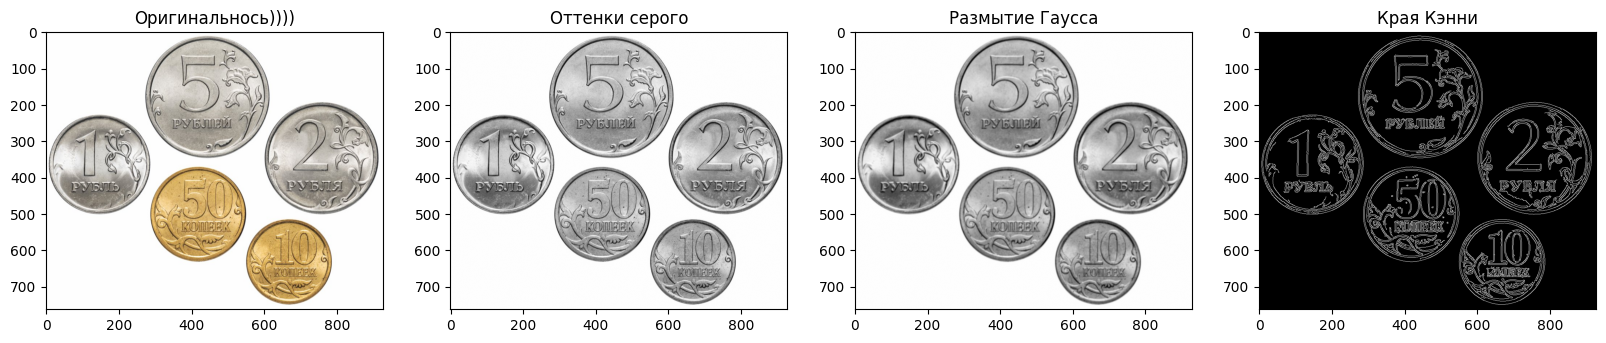

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)
c_anny = cv2.Canny(gray_blurred, 50, 150, apertureSize=3)

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинальнось))))')

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap='gray')
plt.title('Оттенки серого')

plt.subplot(1, 4, 3)
plt.imshow(gray_blurred, cmap='gray')
plt.title('Размытие Гаусса')

plt.subplot(1, 4, 4)
plt.imshow(c_anny, cmap='gray')
plt.title('Края Кэнни')
plt.show()

In [13]:
# Параметры для функции HoughCircles
dp = 1.2                # Параметр разрешения аккумуляторного массива
minDist = 100            # Минимальное расстояние между центрами обнаруженных окружностей
param1 = 50             # Порог для метода Кэнни
param2 = 150            # Порог для функции HoughCircles (чем меньше, тем больше ложных кругов)
minRadius = 50         # Минимальный радиус круга
maxRadius = 250          # Максимальный радиус круга

# Обнаружение кругов
circles = cv2.HoughCircles(gray_blurred, cv2.HOUGH_GRADIENT, dp, minDist,
                           param1=param1, param2=param2,
                           minRadius=minRadius, maxRadius=maxRadius)

In [14]:
small_radius_max = 150
medium_radius_max = 160
total = 0
coin_values = []
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        radius = int(circle[2])
        if radius < small_radius_max:
            value = 1
        elif radius < medium_radius_max:
            value = 2
        else:
            value = 5
        coin_values.append(value)
        total += value
    print("Найдено монет:", len(coin_values))
    print("Номиналы монет:", coin_values)
    print("Общая сумма:", total, "рублей")

Найдено монет: 5
Номиналы монет: [5, 2, 1, 1, 1]
Общая сумма: 10 рублей


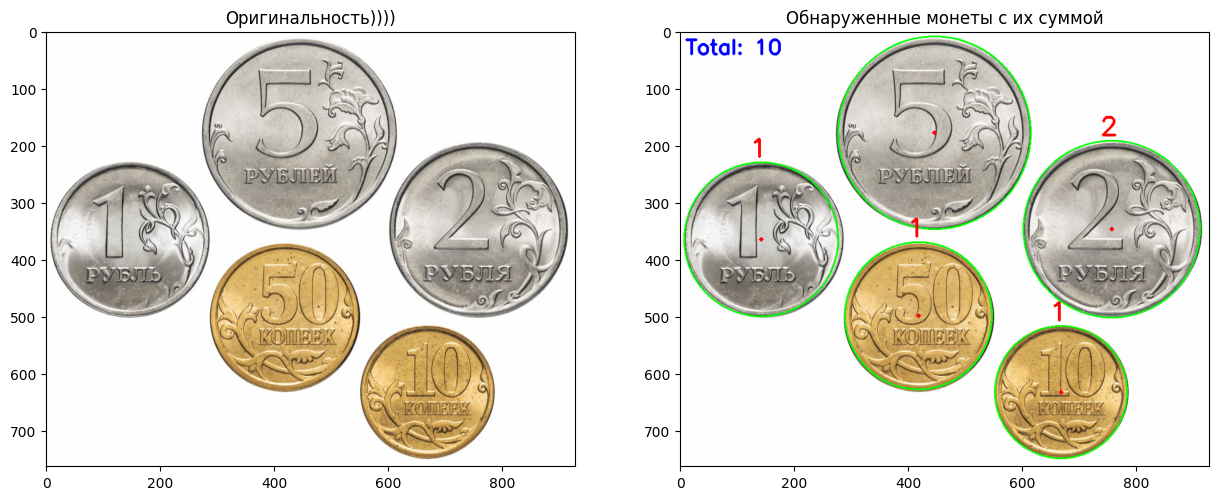

In [15]:
img_circles = img.copy()
if circles is not None:
    for circle, value in zip(circles[0, :], coin_values):
        center = (int(circle[0]), int(circle[1]))
        radius = int(circle[2])
        cv2.circle(img_circles, center, radius, (0, 255, 0), 2)
        cv2.circle(img_circles, center, 2, (0, 0, 255), 3)
        cv2.putText(img_circles, str(value), (center[0] - 20, center[1] - radius - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
    cv2.putText(img_circles, "Total: " + str(total), (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинальность))))')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженные монеты с их суммой')
plt.show()

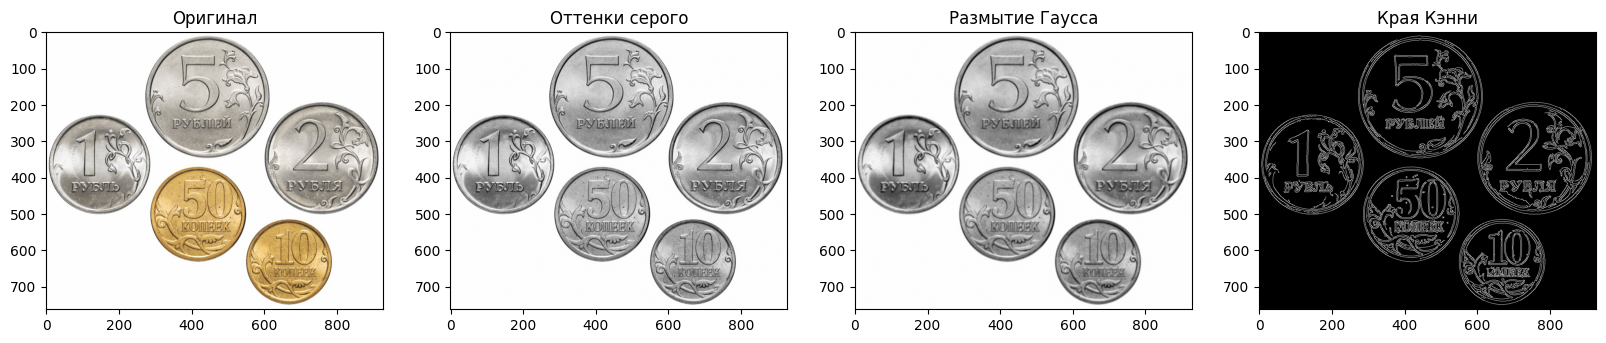

Найдено прямых линий: 147
Найдено монет: 5
Номиналы монет: [5, 2, 1, 1, 1]
Общая сумма: 10 рублей


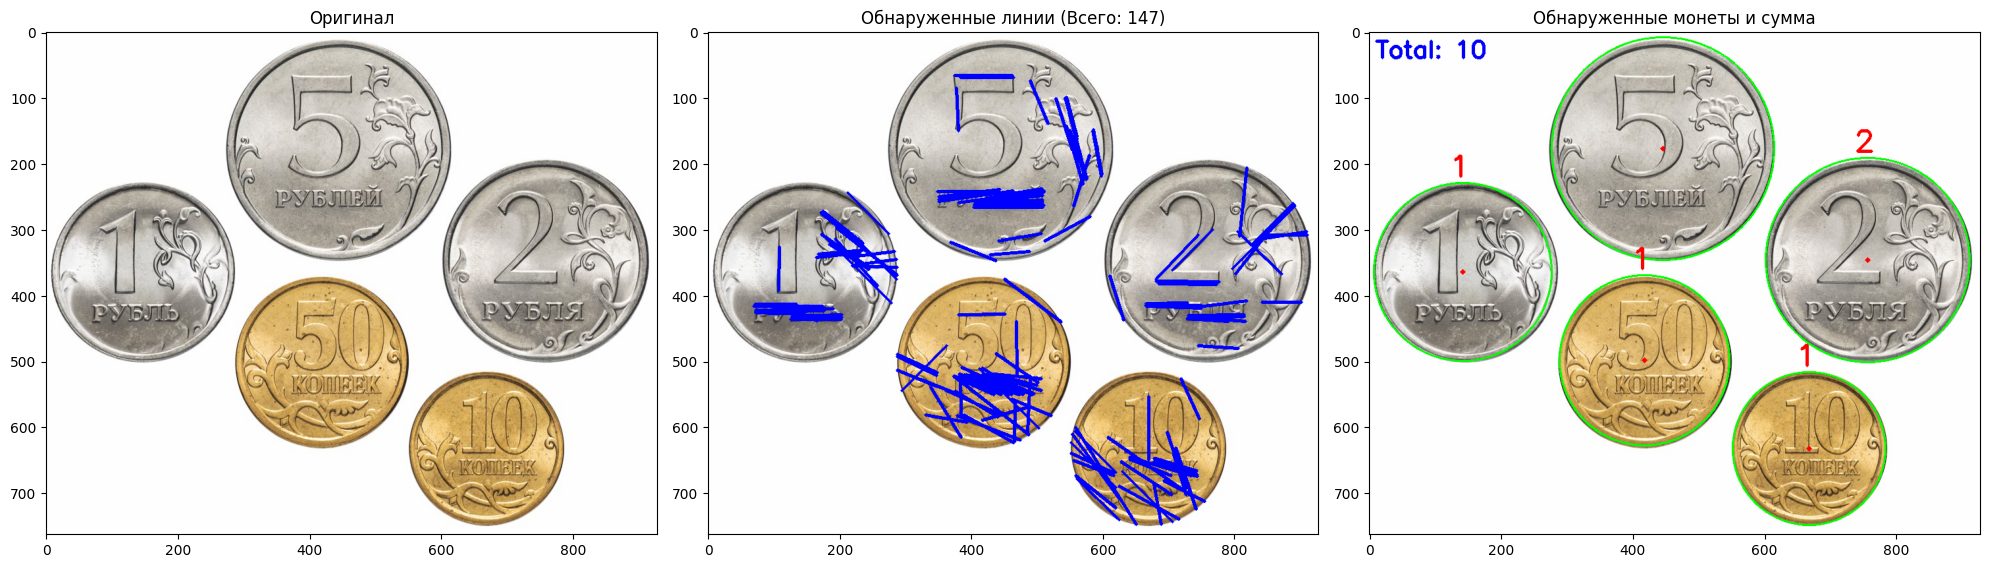

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка и предобработка изображения
img = cv2.imread('coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Выделение краев методом Кэнни (используется и для кругов, и для линий)
c_anny = cv2.Canny(gray_blurred, 50, 150, apertureSize=3)

# Визуализация этапов обработки
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинал')
plt.subplot(1, 4, 2)
plt.imshow(gray, cmap='gray')
plt.title('Оттенки серого')
plt.subplot(1, 4, 3)
plt.imshow(gray_blurred, cmap='gray')
plt.title('Размытие Гаусса')
plt.subplot(1, 4, 4)
plt.imshow(c_anny, cmap='gray')
plt.title('Края Кэнни')
plt.show()

# =========================================================================
# БЛОК 1: ПОИСК ЛИНИЙ (Добавленное требование преподавателя)
# =========================================================================
# Используем вероятностное преобразование Хафа для поиска отрезков прямых
# minLineLength - минимальная длина линии в пикселях
# maxLineGap - максимальный разрыв между сегментами, чтобы они считались одной линией
lines = cv2.HoughLinesP(c_anny, rho=1, theta=np.pi/180, threshold=80, minLineLength=60, maxLineGap=10)

img_lines = img.copy()
lines_count = 0

if lines is not None:
    lines_count = len(lines)
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Рисуем найденные линии синим цветом (толщина 3 пикселя)
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 3)

print("Найдено прямых линий:", lines_count)

# =========================================================================
# БЛОК 2: ПОИСК КРУГОВ И ПОДЧЕТ МОНЕТ (Ваш исходный код)
# =========================================================================
dp = 1.2
minDist = 100
param1 = 50
param2 = 150
minRadius = 50
maxRadius = 250

circles = cv2.HoughCircles(gray_blurred, cv2.HOUGH_GRADIENT, dp, minDist,
                           param1=param1, param2=param2, minRadius=minRadius, maxRadius=maxRadius)

small_radius_max = 150
medium_radius_max = 160
total = 0
coin_values = []

if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        radius = int(circle[2])
        if radius < small_radius_max:
            value = 1
        elif radius < medium_radius_max:
            value = 2
        else:
            value = 5
        coin_values.append(value)
        total += value

print("Найдено монет:", len(coin_values))
print("Номиналы монет:", coin_values)
print("Общая сумма:", total, "рублей")

# Отрисовка кругов и номиналов
img_circles = img.copy()
if circles is not None:
    for circle, value in zip(circles[0, :], coin_values):
        center = (int(circle[0]), int(circle[1]))
        radius = int(circle[2])
        cv2.circle(img_circles, center, radius, (0, 255, 0), 2)
        cv2.circle(img_circles, center, 2, (0, 0, 255), 3)
        cv2.putText(img_circles, str(value), (center[0] - 20, center[1] - radius - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
    cv2.putText(img_circles, "Total: " + str(total), (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)

# =========================================================================
# БЛОК 3: ФИНАЛЬНОЕ СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# =========================================================================
plt.figure(figsize=(20, 8))

# Слева — оригинальное фото
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинал')

# В центре — найденные прямые линии (синие)
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title(f'Обнаруженные линии (Всего: {lines_count})')

# Справа — найденные монеты (зеленые круги)
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженные монеты и сумма')

plt.tight_layout()
plt.show()


In [17]:
# Загрузка изображений монет под разным ракурсом
!curl -L -A "Mozilla/5.0" -o coin1.jpg "https://intofact.ru/wp-content/uploads/2021/09/c91829f468b7be7c163f0fd0cd293900-1.jpg"
!curl -L -A "Mozilla/5.0" -o coin2.jpg "https://cdn.monetnik.ru/storage/market-lot/25/80/677525/2389815_mainViewLot_2x.jpg"
!curl -L -A "Mozilla/5.0" -o coin3.jpg "https://avatars.mds.yandex.net/i?id=32422269e99d9703563a048373b7c555_l-5118202-images-thumbs&n=13"
!curl -L -A "Mozilla/5.0" -o coin4.jpg "https://avatars.mds.yandex.net/i?id=f0a2fda52c32c694a84f430417a64d2c_l-4033154-images-thumbs&n=13"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  169k  100  169k    0     0   175k      0 --:--:-- --:--:-- --:--:--  175k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  148k  100  148k    0     0   132k      0  0:00:01  0:00:01 --:--:--  132k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  272k  100  272k    0     0   223k      0  0:00:01  0:00:01 --:--:--  223k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  369k  100  369k    0     0   348k      0  0:00:01  0:00:01 --:--:--  348k


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_names = ['coin1.jpg', 'coin2.jpg', 'coin3.jpg', 'coin4.jpg']

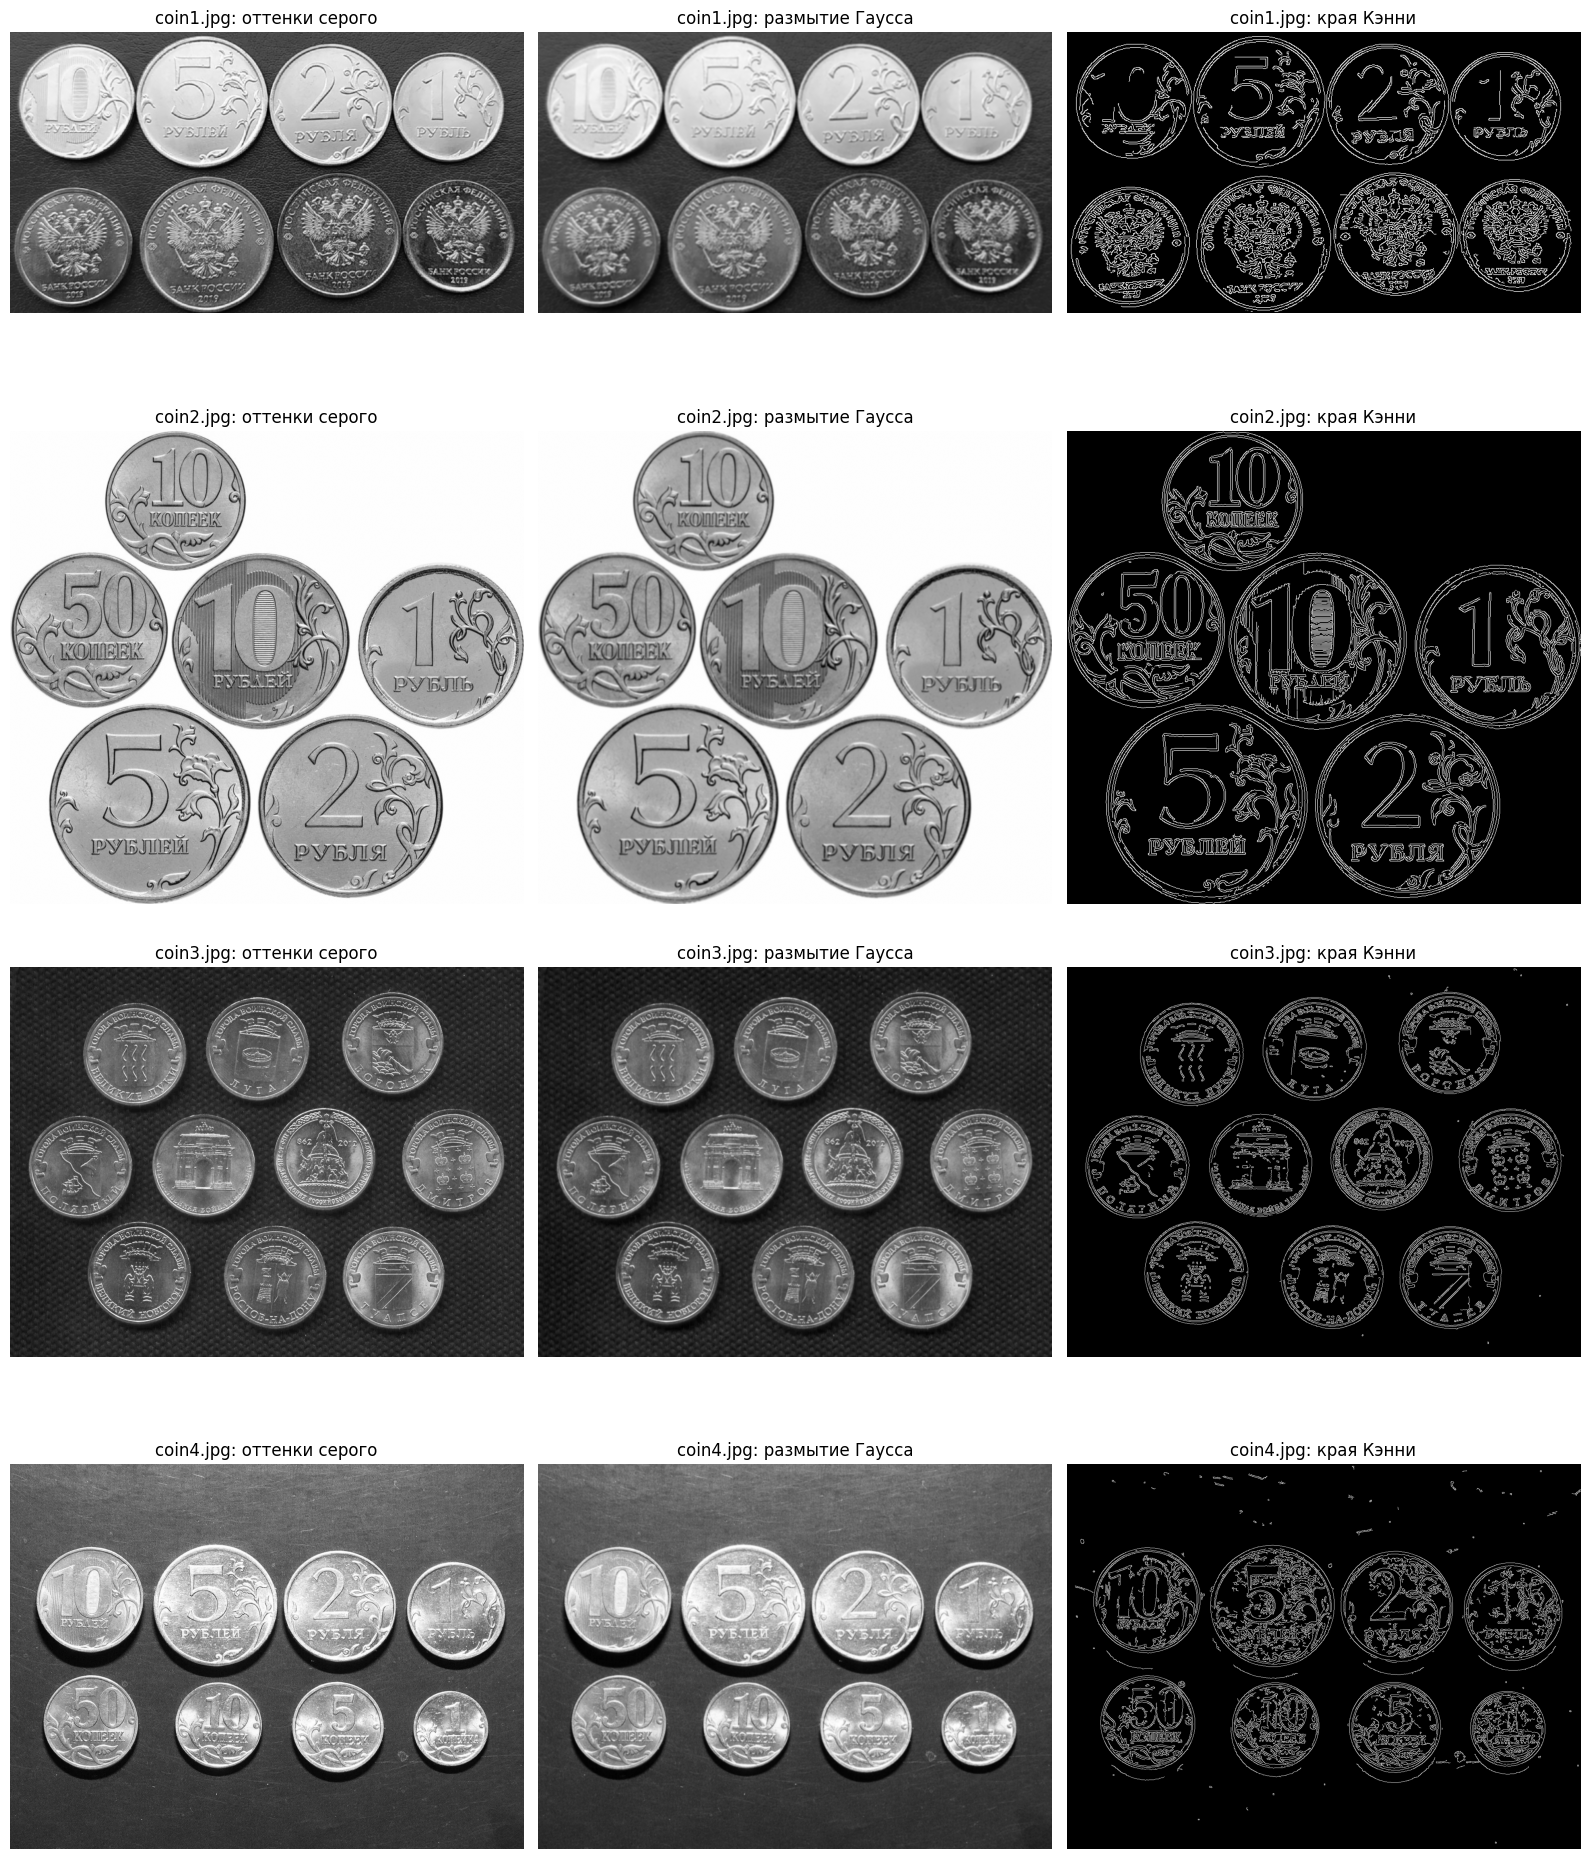

In [19]:
# Демонстрация этапов предварительной обработки для всех изображений
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 20))
for i, image_name in enumerate(image_names):
    img = cv2.imread(image_name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    c_anny = cv2.Canny(gray_blurred, 50, 150, apertureSize=3)

    axes[i, 0].imshow(gray, cmap='gray')
    axes[i, 0].set_title(f'{image_name}: оттенки серого')
    axes[i, 1].imshow(gray_blurred, cmap='gray')
    axes[i, 1].set_title(f'{image_name}: размытие Гаусса')
    axes[i, 2].imshow(c_anny, cmap='gray')
    axes[i, 2].set_title(f'{image_name}: края Кэнни')
    for ax in axes[i]:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
def detect_circles(image, params):
    """Определяет круги (монеты) на изображении с помощью преобразования Хафа."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    if params.get('preprocess') == 'morph':
        # Морфологическое открытие убирает текстуру фона (для фото с узорным фоном)
        kernel = np.ones((7, 7), np.uint8)
        work = cv2.morphologyEx(gray_blurred, cv2.MORPH_OPEN, kernel)
    else:
        work = gray_blurred
    circles = cv2.HoughCircles(work, cv2.HOUGH_GRADIENT, params['dp'], params['minDist'],
                               param1=params['param1'], param2=params['param2'],
                               minRadius=params['minRadius'], maxRadius=params['maxRadius'])
    if circles is None:
        return []
    return np.round(circles[0, :]).astype('int')

# Параметры обнаружения кругов для каждого снимка (подобраны экспериментально,
# т.к. снимки отличаются масштабом и фоном)
DETECTION_PARAMS = {
    'coin1.jpg': dict(preprocess='morph', dp=1.2, minDist=35, param1=80, param2=120, minRadius=35, maxRadius=130),
    'coin2.jpg': dict(preprocess='gauss', dp=1.2, minDist=68, param1=80, param2=200, minRadius=68, maxRadius=384),
    'coin3.jpg': dict(preprocess='gauss', dp=1.2, minDist=78, param1=80, param2=200, minRadius=78, maxRadius=442),
    'coin4.jpg': dict(preprocess='gauss', dp=1.2, minDist=96, param1=80, param2=180, minRadius=75, maxRadius=350),
}

In [21]:
def detect_lines_in_circle(image, cx, cy, r, canny_low=50, canny_high=150,
                           hough_thresh=20, min_line_len=10, max_line_gap=5):
    """Вырезает монету по маске (круг) и ищет линии внутри неё."""
    h, w = image.shape[:2]

    # Маска-круг для вырезания монеты
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (cx, cy), r, 255, -1)

    x1 = max(cx - r, 0)
    y1 = max(cy - r, 0)
    x2 = min(cx + r, w)
    y2 = min(cy + r, h)
    roi = image[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    # Края внутри вырезанной монеты (с учётом маски)
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY) if roi.ndim == 3 else roi
    roi_blur = cv2.GaussianBlur(roi_gray, (3, 3), 0)
    roi_edges = cv2.Canny(roi_blur, canny_low, canny_high)
    roi_edges = cv2.bitwise_and(roi_edges, roi_edges, mask=roi_mask)

    # Поиск линий
    lines = cv2.HoughLinesP(
        roi_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_thresh,
        minLineLength=min_line_len,
        maxLineGap=max_line_gap
    )

    result_lines = []
    if lines is not None:
        lines = lines.reshape(-1, 4)
        for lx1, ly1, lx2, ly2 in lines:
            result_lines.append([int(lx1) + x1, int(ly1) + y1,
                                 int(lx2) + x1, int(ly2) + y1])

    # Полная карта краёв (для визуализации)
    full_edges = np.zeros((h, w), dtype=np.uint8)
    full_edges[y1:y2, x1:x2] = roi_edges

    return result_lines, full_edges

def count_lines(lines):
    """Считает количество вертикальных и горизонтальных линий."""
    vertical_count = 0
    horizontal_count = 0
    for (x1, y1, x2, y2) in lines:
        dx, dy = x2 - x1, y2 - y1
        angle = np.degrees(np.arctan2(dy, dx)) % 180
        if angle < 20 or angle > 160:
            horizontal_count += 1
        elif 70 < angle < 110:
            vertical_count += 1
    return vertical_count, horizontal_count

In [22]:
# Эталонные значения для классификации: (номинал, радиус, вертикальные, горизонтальные линии).
# Для каждого снимка своя таблица, т.к. масштаб фотографий разный.
# Значения откалиброваны по этим снимкам (как в эталонном ноутбуке).
COINS = {
    'coin1.jpg': [(1, 86, 52, 52), (2, 94, 54, 56), (5, 102, 46, 71), (10, 90, 48, 42)],
    'coin2.jpg': [(0.1, 127, 71, 151), (0.5, 140, 88, 154), (1, 146, 167, 89),
                  (2, 164, 168, 138), (5, 181, 189, 190), (10, 159, 460, 74)],
    'coin3.jpg': [(10, 128, 102, 130)],
    'coin4.jpg': [(1, 118, 173, 134), (1, 93, 108, 98),
                  (2, 135, 189, 178), (2, 112, 126, 144),
                  (5, 153, 331, 226),
                  (10, 118, 97, 159), (10, 124, 229, 89), (10, 107, 144, 122)],
}

TOLERANCE = {"radius": 8, "vertical": 40, "horizontal": 40}

def _vote(value, refs, tol):
    in_range = [(nom, abs(value - ref)) for nom, ref in refs if abs(value - ref) <= tol]
    if in_range:
        return min(in_range, key=lambda x: (x[1], x[0]))[0]
    return min(refs, key=lambda kv: abs(value - kv[1]))[0]

def classify_coin(image_name, radius, vertical_count, horizontal_count):
    """Определяет номинал голосованием по трём критериям (радиус + линии), как в эталоне."""
    table = COINS[image_name]
    votes_by_criterion = {
        "radius":     _vote(radius, [(n, r) for n, r, v, h in table], TOLERANCE["radius"]),
        "vertical":   _vote(vertical_count, [(n, v) for n, r, v, h in table], TOLERANCE["vertical"]),
        "horizontal": _vote(horizontal_count, [(n, h) for n, r, v, h in table], TOLERANCE["horizontal"]),
    }

    vote_counts = {nom: 0 for nom, *_ in table}
    for nom in votes_by_criterion.values():
        vote_counts[nom] += 1

    if max(vote_counts.values()) == 1:
        return votes_by_criterion["radius"], votes_by_criterion

    max_count = max(vote_counts.values())
    tied = [nom for nom, cnt in vote_counts.items() if cnt == max_count]

    if len(tied) == 1:
        winner = tied[0]
    else:
        winner = (votes_by_criterion["radius"]
                  if votes_by_criterion["radius"] in tied
                  else min(tied))

    return winner, votes_by_criterion

Монета 0: r=94, V=54, H=56 -> 2 руб.
Монета 1: r=102, V=46, H=71 -> 5 руб.
Монета 2: r=86, V=52, H=52 -> 1 руб.
Монета 3: r=90, V=48, H=42 -> 10 руб.
--- coin1.jpg ---
Найдено монет: 4
Номиналы монет: [2, 5, 1, 10]
Общая сумма: 18 рублей



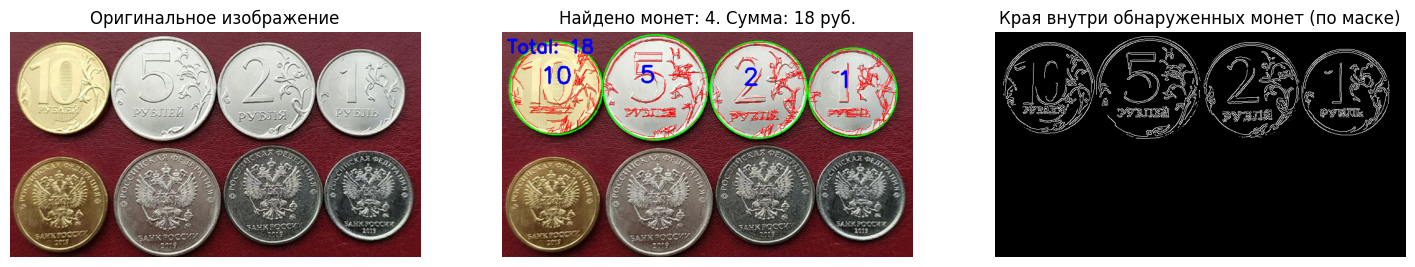

Монета 0: r=159, V=460, H=74 -> 10 руб.
Монета 1: r=181, V=189, H=190 -> 5 руб.
Монета 2: r=146, V=167, H=89 -> 1 руб.
Монета 3: r=164, V=168, H=138 -> 2 руб.
Монета 4: r=127, V=71, H=151 -> 0.1 руб.
Монета 5: r=140, V=88, H=154 -> 0.5 руб.
--- coin2.jpg ---
Найдено монет: 6
Номиналы монет: [10, 5, 1, 2, 0.1, 0.5]
Общая сумма: 18.6 рублей



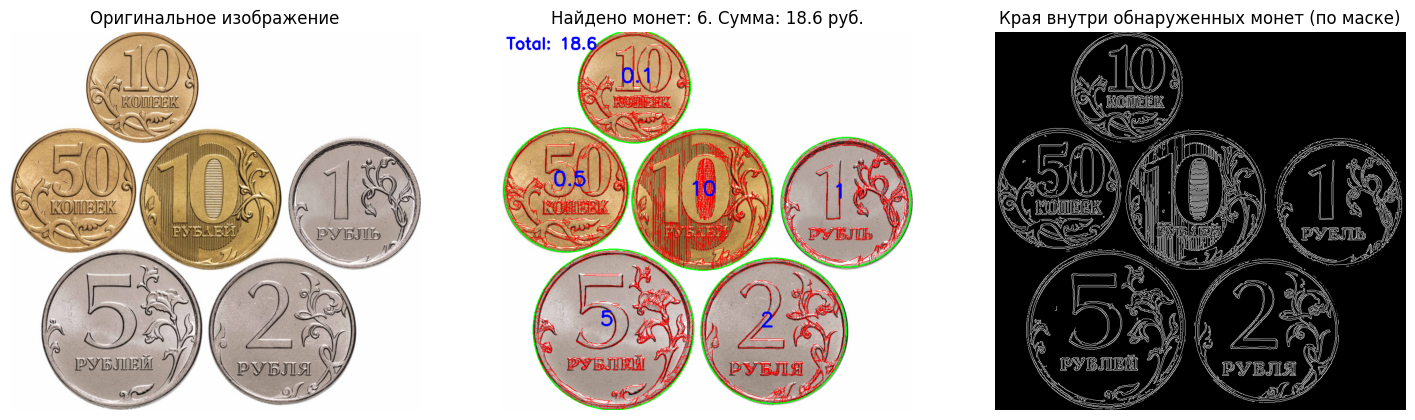

Монета 0: r=130, V=68, H=126 -> 10 руб.
Монета 1: r=130, V=98, H=115 -> 10 руб.
Монета 2: r=121, V=90, H=142 -> 10 руб.
Монета 3: r=129, V=122, H=123 -> 10 руб.
Монета 4: r=129, V=100, H=183 -> 10 руб.
Монета 5: r=121, V=61, H=131 -> 10 руб.
Монета 6: r=125, V=139, H=93 -> 10 руб.
Монета 7: r=124, V=69, H=150 -> 10 руб.
Монета 8: r=119, V=135, H=126 -> 10 руб.
Монета 9: r=129, V=140, H=106 -> 10 руб.
--- coin3.jpg ---
Найдено монет: 10
Номиналы монет: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
Общая сумма: 100 рублей



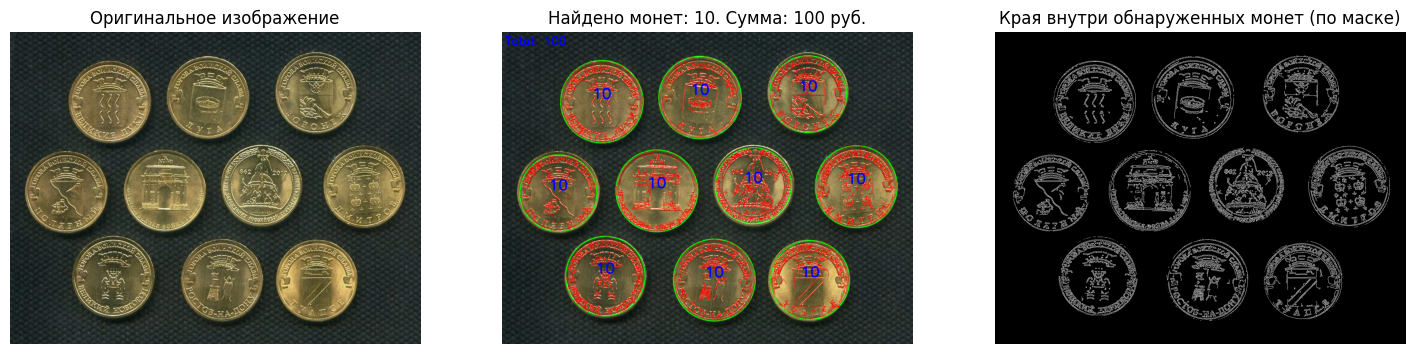

Монета 0: r=118, V=97, H=159 -> 10 руб.
Монета 1: r=135, V=189, H=178 -> 2 руб.
Монета 2: r=153, V=331, H=226 -> 5 руб.
Монета 3: r=112, V=126, H=144 -> 2 руб.
Монета 4: r=124, V=229, H=89 -> 10 руб.
Монета 5: r=107, V=144, H=122 -> 10 руб.
Монета 6: r=118, V=173, H=134 -> 1 руб.
Монета 7: r=93, V=108, H=98 -> 1 руб.
--- coin4.jpg ---
Найдено монет: 8
Номиналы монет: [10, 2, 5, 2, 10, 10, 1, 1]
Общая сумма: 41 рублей



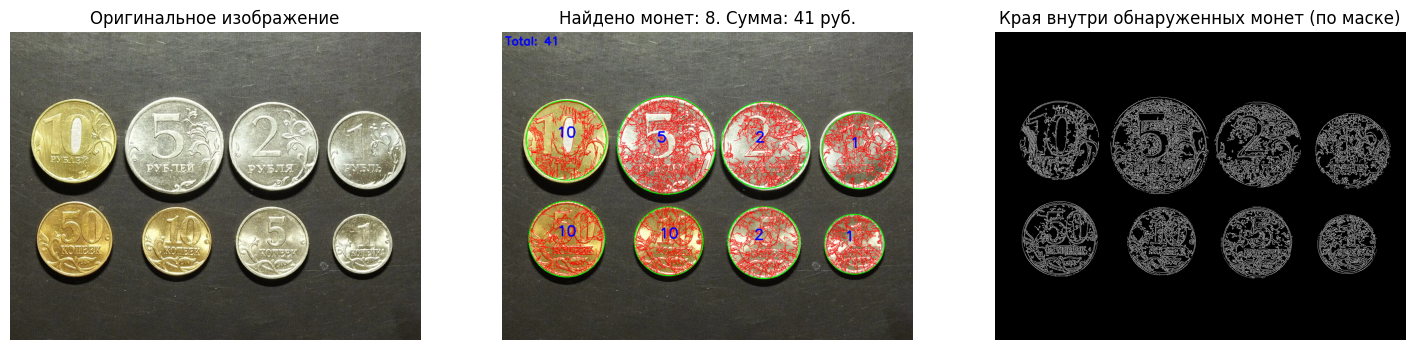

ИТОГО по всем изображениям: монет = 28, сумма = 177.6 рублей


In [23]:
grand_total = 0
grand_count = 0

for image_name in image_names:
    img = cv2.imread(image_name)
    params = DETECTION_PARAMS[image_name]
    circles = detect_circles(img, params)

    # Обработка случая, когда монеты не обнаружены
    if len(circles) == 0:
        print(f"{image_name}: монеты не обнаружены, попробуйте изменить параметры")
        continue

    result = img.copy()
    all_edges = np.zeros(img.shape[:2], dtype=np.uint8)
    coin_values = []
    coin_info = []

    for i, (cx, cy, r) in enumerate(circles):
        # Вырезаем монету по маске и ищем линии внутри неё
        lines, edges = detect_lines_in_circle(img, cx, cy, r)
        # Считаем горизонтальные и вертикальные линии
        vertical_count, horizontal_count = count_lines(lines)
        # Классификация голосованием (радиус + количество линий)
        nominal, votes = classify_coin(image_name, r, vertical_count, horizontal_count)
        coin_values.append(nominal)
        coin_info.append((i, cx, cy, r, vertical_count, horizontal_count, nominal))

        # Отрисовка: круг монеты + найденные линии
        cv2.circle(result, (cx, cy), r, (0, 255, 0), 2)
        for (x1, y1, x2, y2) in lines:
            cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 1)
        all_edges = cv2.bitwise_or(all_edges, edges)

        print(f"Монета {i}: r={r}, V={vertical_count}, H={horizontal_count} -> {nominal} руб.")

    total = sum(coin_values)

    # Подписи номиналов и общей суммы на изображении
    for (i, cx, cy, r, v, h, nominal) in coin_info:
        cv2.putText(result, str(nominal), (cx - 30, cy - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)
    cv2.putText(result, "Total: " + str(total), (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)

    print(f"--- {image_name} ---")
    print("Найдено монет:", len(coin_values))
    print("Номиналы монет:", coin_values)
    print("Общая сумма:", total, "рублей")
    print()

    grand_total += total
    grand_count += len(coin_values)

    # Визуализация: оригинал | результат с линиями | края внутри монет
    plt.figure(figsize=(18, 8))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Оригинальное изображение')
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Найдено монет: {len(coin_values)}. Сумма: {total} руб.')
    plt.subplot(1, 3, 3)
    plt.imshow(all_edges, cmap='gray')
    plt.axis('off')
    plt.title('Края внутри обнаруженных монет (по маске)')
    plt.show()

print(f"ИТОГО по всем изображениям: монет = {grand_count}, сумма = {grand_total} рублей")